# Customer Service Management 

### Table of Contents: 

- import the needed libraries 
- Read teh Data 
- Preprocessing the data and cleaning data 
- Extract and Scale the features 
- Hierarchical Clustering
- K-Means Clustering
- DBSCAN Clustering
- Visualization the outputs and results 

## Import necessary libraries

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt


## Read the DataSet

In [25]:
file_path = 'Customer.csv'
df = pd.read_csv(file_path)


## PreProcessing

In [26]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


## Extract the features 

In [27]:
features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


## Scale the features 

In [28]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


## Hierarchical

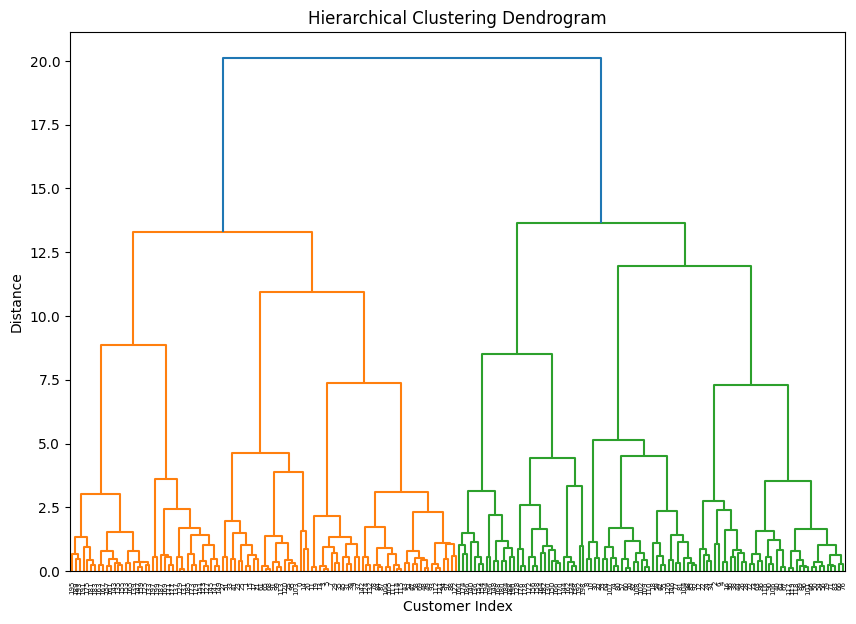

In [29]:
Z = linkage(scaled_features, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()


## K-Means 

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)


## Choosing the dendrogram

In [31]:
df['Hierarchical_Cluster'] = fcluster(Z, t=5, criterion='maxclust')


## DBSCAN

In [32]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)


## Visualization 

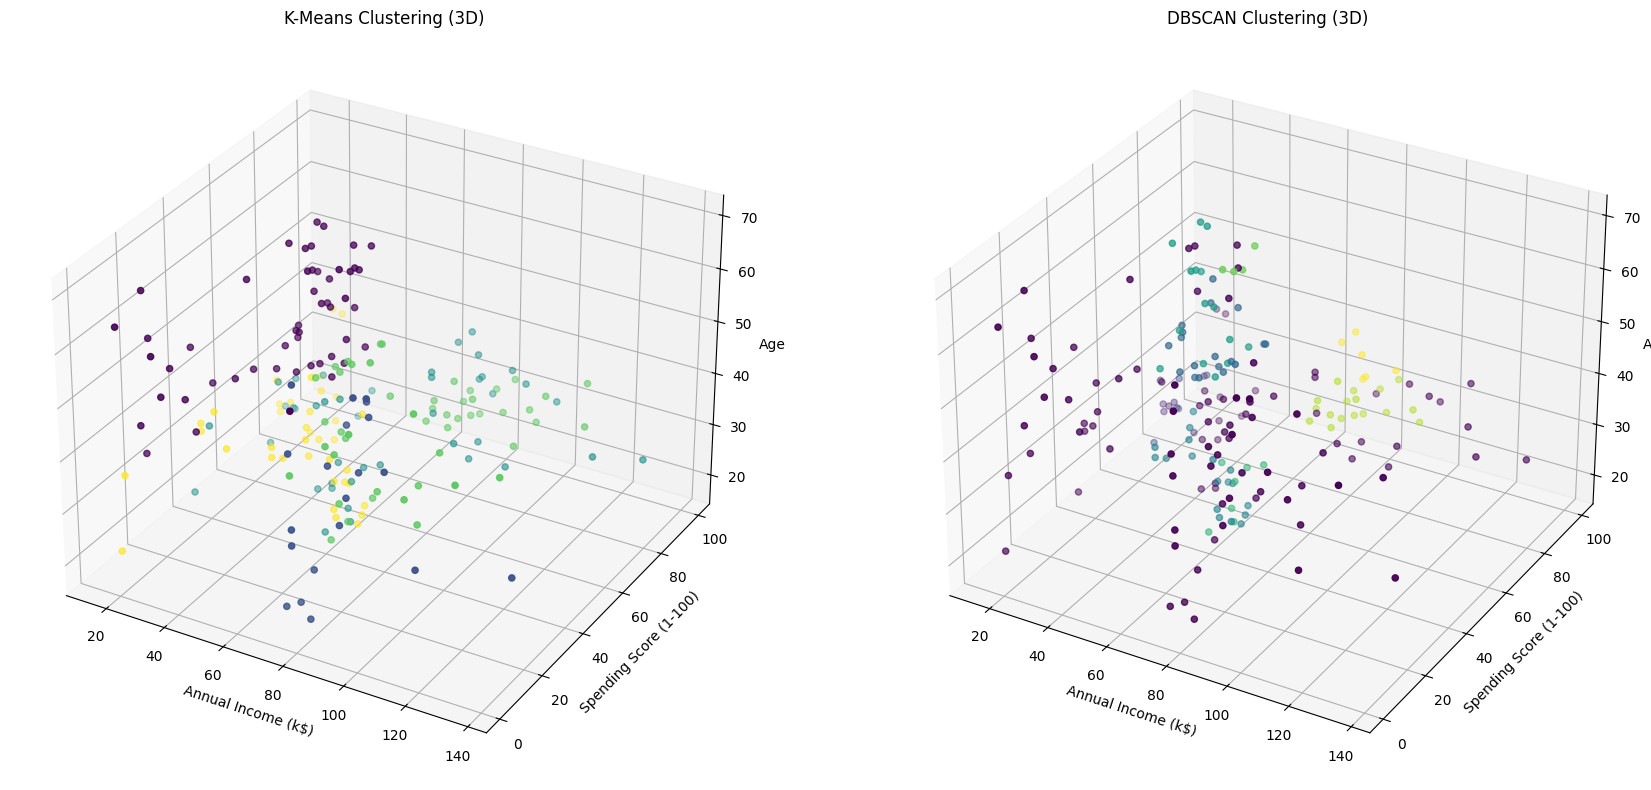

In [33]:
fig = plt.figure(figsize=(18, 8))

# K-Means
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'], c=df['KMeans_Cluster'], cmap='viridis')
ax1.set_title('K-Means Clustering (3D)')
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')
ax1.set_zlabel('Age')

# DBSCAN Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'], c=df['DBSCAN_Cluster'], cmap='viridis')
ax2.set_title('DBSCAN Clustering (3D)')
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.set_zlabel('Age')


plt.tight_layout()


plt.show()

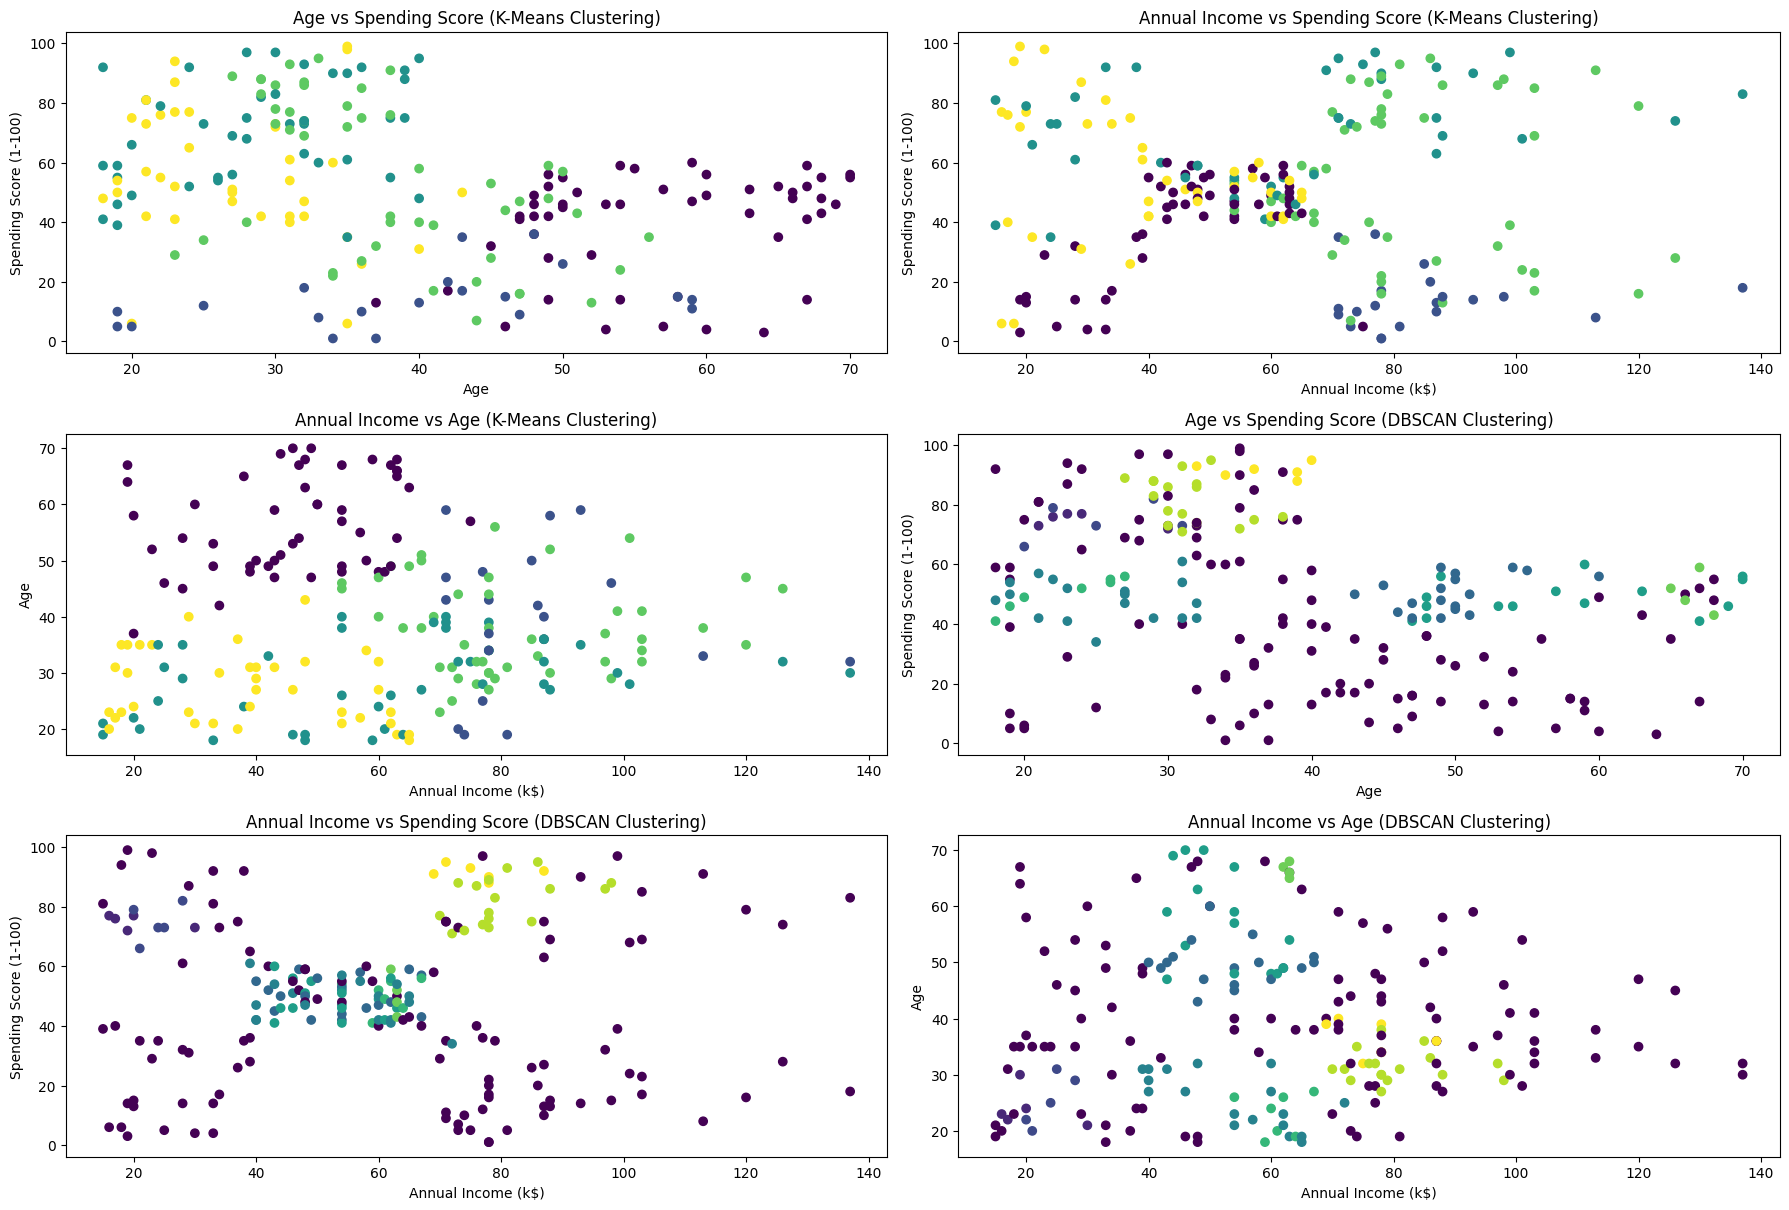

In [34]:

fig = plt.figure(figsize=(18, 16))





# 2D - Age | Spending Score (K-Means)
ax3 = fig.add_subplot(423)
ax3.scatter(df['Age'], df['Spending Score (1-100)'], c=df['KMeans_Cluster'], cmap='viridis')
ax3.set_title('Age vs Spending Score (K-Means Clustering)')
ax3.set_xlabel('Age')
ax3.set_ylabel('Spending Score (1-100)')



# 2D - Annual Income | Spending Score (K-Means)
ax4 = fig.add_subplot(424)
ax4.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['KMeans_Cluster'], cmap='viridis')
ax4.set_title('Annual Income vs Spending Score (K-Means Clustering)')
ax4.set_xlabel('Annual Income (k$)')
ax4.set_ylabel('Spending Score (1-100)')



# 2D - Annual Income | Age (K-Means)
ax5 = fig.add_subplot(425)
ax5.scatter(df['Annual Income (k$)'], df['Age'], c=df['KMeans_Cluster'], cmap='viridis')
ax5.set_title('Annual Income vs Age (K-Means Clustering)')
ax5.set_xlabel('Annual Income (k$)')
ax5.set_ylabel('Age')



# 2D - Age | Spending Score (DBSCAN)
ax6 = fig.add_subplot(426)
ax6.scatter(df['Age'], df['Spending Score (1-100)'], c=df['DBSCAN_Cluster'], cmap='viridis')
ax6.set_title('Age vs Spending Score (DBSCAN Clustering)')
ax6.set_xlabel('Age')
ax6.set_ylabel('Spending Score (1-100)')



# 2D - Annual Income | Spending Score (DBSCAN)
ax7 = fig.add_subplot(427)
ax7.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['DBSCAN_Cluster'], cmap='viridis')
ax7.set_title('Annual Income vs Spending Score (DBSCAN Clustering)')
ax7.set_xlabel('Annual Income (k$)')
ax7.set_ylabel('Spending Score (1-100)')



# 2D - Annual Income | Age (DBSCAN)
ax8 = fig.add_subplot(428)
ax8.scatter(df['Annual Income (k$)'], df['Age'], c=df['DBSCAN_Cluster'], cmap='viridis')
ax8.set_title('Annual Income vs Age (DBSCAN Clustering)')
ax8.set_xlabel('Annual Income (k$)')
ax8.set_ylabel('Age')





plt.tight_layout()


plt.show()
